# Implementing RNN
This problem is naturally sequential so the RNN is the most natural next step.
An RNN processes the sequence one value at a time and the important idea is that the RNN maintains a hidden state that carries information from earlier time steps.

In [3]:
# import modules
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import TensorDataset, DataLoader

In [4]:
# load the data
data = np.loadtxt("mass_spring_data.csv", delimiter=",", skiprows=1)

t = data[:, 0]
x = data[:, 2]

In [5]:
# create sequence dataset
window_size = 50

X = []
y = []

for i in range(len(x) - window_size):

    X.append(x[i:i + window_size])

    y.append(x[i + window_size])

X = np.array(X)
y = np.array(y)

In [6]:
# split dataset
split_index = int(0.7 * len(X))

X_train = X[:split_index]
y_train = y[:split_index]

X_test = X[split_index:]
y_test = y[split_index:]

In [7]:
# conver to tensors
X_train = torch.tensor(X_train, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)

X_test = torch.tensor(X_test, dtype=torch.float32)

y_test = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1)

X_train = X_train.unsqueeze(-1)
X_test = X_test.unsqueeze(-1)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

X_train: torch.Size([1365, 50, 1])
y_train: torch.Size([1365, 1])


In [8]:
# dataloaders
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [9]:
# build rnn
class RNNModel(nn.Module):

    def __init__(self):
        super().__init__()

        self.rnn = nn.RNN(input_size=1, hidden_size=32, num_layers=1, batch_first=True)

        self.output_layer = nn.Linear(32, 1)

    def forward(self, x):

        # x shape:
        # [batch, sequence, features]

        output, hidden = self.rnn(x)

        # Take the output from the final time step
        last_output = output[:, -1, :]

        prediction = self.output_layer(last_output)

        return prediction

In [10]:
# create model
model = RNNModel()

print(model)

RNNModel(
  (rnn): RNN(1, 32, batch_first=True)
  (output_layer): Linear(in_features=32, out_features=1, bias=True)
)


In [11]:
# loss and optimizer
loss_function = nn.MSELoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [12]:
# train
epochs = 50

loss_history = []

for epoch in range(epochs):

    model.train()

    total_loss = 0.0

    for X_batch, y_batch in train_loader:

        # Forward pass
        prediction = model(X_batch)

        # Loss
        loss = loss_function(prediction, y_batch)

        # Clear old gradients
        optimizer.zero_grad()

        # Backpropagation
        loss.backward()

        # Update parameters
        optimizer.step()

        total_loss += loss.item()

    average_loss = (total_loss / len(train_loader))

    loss_history.append(average_loss)

    if epoch % 5 == 0:

        print(f"Epoch {epoch:3d} | "f"Loss = {average_loss:.8f}")

Epoch   0 | Loss = 0.27253968
Epoch   5 | Loss = 0.00082258
Epoch  10 | Loss = 0.00019753
Epoch  15 | Loss = 0.00016118
Epoch  20 | Loss = 0.00013962
Epoch  25 | Loss = 0.00011713
Epoch  30 | Loss = 0.00010927
Epoch  35 | Loss = 0.00007988
Epoch  40 | Loss = 0.00007787
Epoch  45 | Loss = 0.00006386


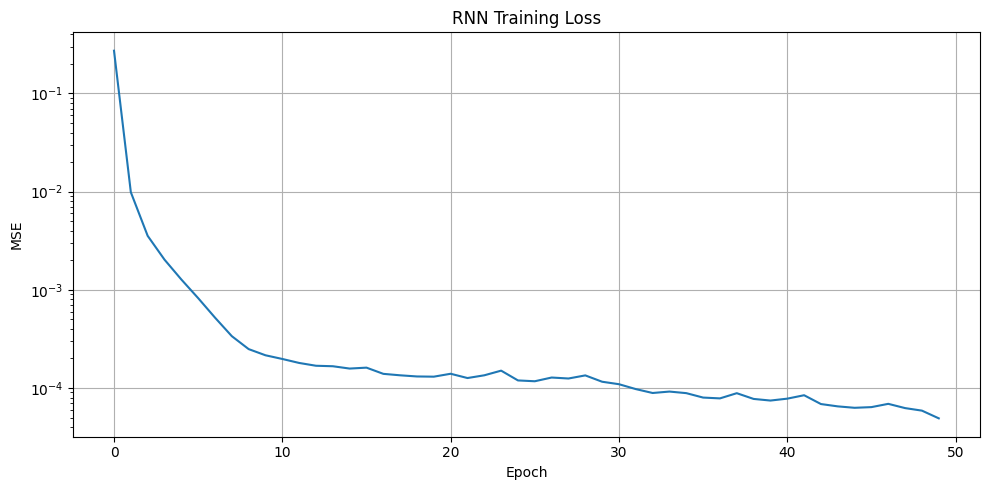

In [13]:
# plot loss
plt.figure(figsize=(10, 5))

plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("RNN Training Loss")

plt.yscale("log")
plt.grid()
plt.tight_layout()

plt.show()

In [14]:
# evaluation
model.eval()

predictions = []
actual = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        prediction = model(X_batch)

        predictions.append(prediction.numpy())

        actual.append(y_batch.numpy())


predictions = np.concatenate(predictions).flatten()

actual = np.concatenate(actual).flatten()

In [15]:
# calculate mse and rmse
mse = np.mean((predictions - actual) ** 2)

rmse = np.sqrt(mse)

print()
print("==============================")
print("RNN Performance")
print("==============================")
print(f"MSE  = {mse:.8e}")
print(f"RMSE = {rmse:.8e}")
print()


RNN Performance
MSE  = 3.97978329e-05
RMSE = 6.30855234e-03



In [16]:
# time corresponding to test targets
test_start = split_index + window_size

t_test = t[test_start:]

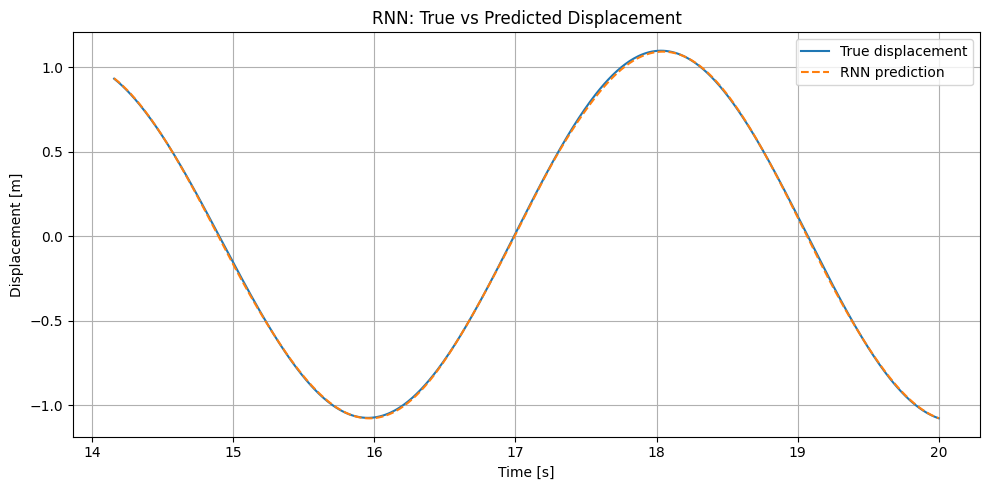

In [17]:
# plot prediction
plt.figure(figsize=(10, 5))

plt.plot(t_test, actual, label="True displacement")

plt.plot(t_test, predictions, "--", label="RNN prediction")

plt.xlabel("Time [s]")
plt.ylabel("Displacement [m]")

plt.title("RNN: True vs Predicted Displacement")

plt.legend()
plt.grid()
plt.tight_layout()

plt.show()

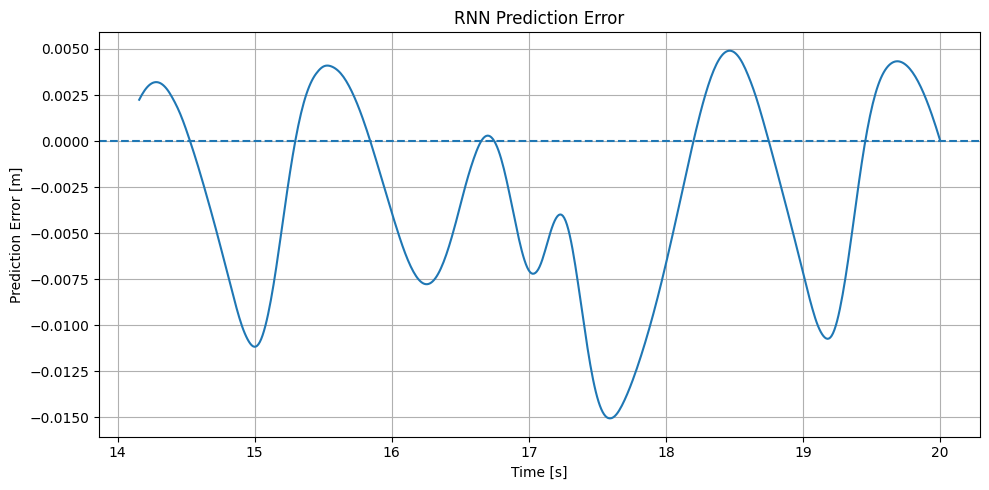

In [18]:
# prediction error
error = predictions - actual

plt.figure(figsize=(10, 5))

plt.plot(t_test, error)

plt.axhline(0, linestyle="--")

plt.xlabel("Time [s]")
plt.ylabel("Prediction Error [m]")

plt.title("RNN Prediction Error")

plt.grid()
plt.tight_layout()

plt.show()

In [25]:
# evaluate with only giving the model the first 50 data points and feed the prediction as the input set
model.eval()

window = list(x[split_index : split_index + window_size])
rollout_preds = []

with torch.no_grad():
    for _ in range(len(x) - test_start):
        inp = torch.tensor(window[-window_size:], dtype=torch.float32)
        inp = inp.reshape(1, window_size, 1)
        next_val = model(inp).item()
        rollout_preds.append(next_val)
        window.append(next_val)

rollout_preds = np.array(rollout_preds)

In [26]:
# rollout mse and rmse
rollout_mse = np.mean((rollout_preds - actual) ** 2)
rollout_rmse = np.sqrt(rollout_mse)

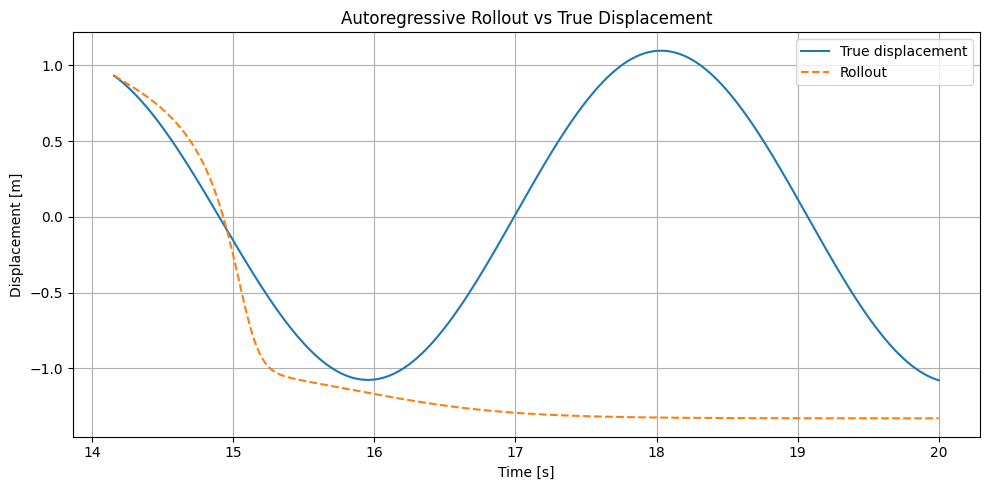

In [27]:
# plot rollout
plt.figure(figsize=(10, 5))

plt.plot(t_test, actual, label="True displacement")
plt.plot(t_test, rollout_preds, "--", label="Rollout")
plt.xlabel("Time [s]")
plt.ylabel("Displacement [m]")

plt.title("Autoregressive Rollout vs True Displacement")

plt.legend()
plt.grid()
plt.tight_layout()

plt.show()